# Idea 29: Competitive Item Substitution

## 1. Hypothesis and Setup

**Question:** Which items act as substitutes within a customer's purchase patterns (i.e., they are rarely or never bought together by the same customer)?

**Hypothesis:** In 'staple' categories (Milk, Diapers), customers exhibit strict mutual exclusivity. If they buy Brand A, they will actively avoid Brand B. Identifying these substitutes prevents the recommendation engine from wasting slots showing alternatives when the customer has already chosen a substitute.

**Datasets:**
- `transaction_full_2025.parquet`
- `items.parquet`

**Method (FULL SCALE):**
1. **Lazy Filtering:** Find all items with at least 5 sales (to remove noise).
2. **Full Transaction Load:** Collect all 37.6M transaction rows for these items into RAM (~1.5GB total).
3. **Iterative Pairing:** Process one category at a time. This keeps memory usage extremely low by only forming pairs within a single `category_l2` bucket.

**Decision Rule:** KEEP if >10 strong substitution pairs emerge (strength > 1.5).

In [9]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

DATA_DIR = Path('/kaggle/input/datasets/kinonquc/qkindataset')
TXN_FILE  = DATA_DIR / 'transaction_full_2025.parquet'
ITEMS_FILE = DATA_DIR / 'items.parquet'
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Full Catalog Load

In [10]:
# 1. Find all items with >= 5 sales to filter absolute tail noise
active_items = (
    pl.scan_parquet(TXN_FILE)
    .group_by('item_id')
    .len()
    .filter(pl.col('len') >= 5)
    .collect()
)
active_item_ids = set(active_items['item_id'].to_list())

# 2. Load Metadata for these items
items_meta = (
    pl.scan_parquet(ITEMS_FILE)
    .select(['item_id', 'category_l2', 'brand', 'description'])
    .filter(pl.col('item_id').is_in(active_item_ids))
    .collect()
)

# 3. Load ALL Transactions for these items (~37M rows)
txn_full = (
    pl.scan_parquet(TXN_FILE)
    .select(['customer_id', 'item_id'])
    .filter(pl.col('item_id').is_in(active_item_ids))
    .collect()
)

total_cust = pl.scan_parquet(TXN_FILE).select('customer_id').unique().collect().height
print(f'Working with {len(items_meta):,} active items. Total transactions: {len(txn_full):,}')
print(f'Total customers in full dataset: {total_cust:,}')

Working with 15,669 active items. Total transactions: 37,676,845
Total customers in full dataset: 2,821,898


## 3. Iterative Calculation (All Categories)

In [11]:
# Mapping dicts
prob_dict = {row['item_id']: row['len'] / total_cust for row in active_items.to_dicts()}
cat_dict = dict(zip(items_meta['item_id'], items_meta['category_l2']))
brand_dict = dict(zip(items_meta['item_id'], items_meta['brand']))
desc_dict = dict(zip(items_meta['item_id'], items_meta['description']))

unique_cats = items_meta['category_l2'].unique().to_list()
all_pairs = []

print(f'Processing {len(unique_cats)} categories iteratively...')
for cat in unique_cats:
    cat_item_ids = items_meta.filter(pl.col('category_l2') == cat)['item_id'].to_list()
    if len(cat_item_ids) < 2: continue
    
    # Get customer-item matrix for this category
    cat_txn = txn_full.filter(pl.col('item_id').is_in(cat_item_ids)).select(['customer_id', 'item_id']).unique()
    
    # Join within category
    cat_co = (
        cat_txn.join(cat_txn, on='customer_id', suffix='_2')
        .filter(pl.col('item_id') < pl.col('item_id_2'))
        .group_by(['item_id', 'item_id_2'])
        .agg((pl.len() / total_cust).alias('p_ab'))
    )
    
    if len(cat_co) > 0: all_pairs.append(cat_co)

if all_pairs:
    co_pd = pl.concat(all_pairs).to_pandas()
    co_pd['cat_1'] = co_pd['item_id'].map(cat_dict)
    co_pd['p_a'] = co_pd['item_id'].map(prob_dict)
    co_pd['p_b'] = co_pd['item_id_2'].map(prob_dict)
    co_pd['expected_p_ab'] = co_pd['p_a'] * co_pd['p_b']
    co_pd['lift'] = co_pd['p_ab'] / co_pd['expected_p_ab']
    co_pd['sub_strength'] = co_pd['expected_p_ab'] / (co_pd['p_ab'] + 1e-8)
    co_pd['brand_1'] = co_pd['item_id'].map(brand_dict)
    co_pd['brand_2'] = co_pd['item_id_2'].map(brand_dict)
    
    substitutes = co_pd[(co_pd['sub_strength'] > 1.5) & (co_pd['brand_1'] != co_pd['brand_2'])].sort_values('sub_strength', ascending=False)
    print(f'\nCalculation Complete. Found {len(substitutes):,} strong competitive substitution pairs.')
    print('\nTop 15 Strongest Substitution Pairs:')
    print(substitutes[['cat_1', 'brand_1', 'brand_2', 'lift', 'sub_strength']].head(15))
else:
    print('No co-purchase pairs found within categories.')
    substitutes = pd.DataFrame()

Processing 123 categories iteratively...

Calculation Complete. Found 1,401 strong competitive substitution pairs.

Top 15 Strongest Substitution Pairs:
            cat_1                  brand_1                   brand_2  \
831582       Enfa                  Enfa A+              Enfa Enspire   
831799       Enfa               Nutramigen              Enfa Enspire   
831849       Enfa               Nutramigen                   Enfa A+   
831967       Enfa               Nutramigen                   Enfa A+   
1695521    Nestle  Nestle NAN Optipro PLUS                Nestle S26   
831792       Enfa                  Enfa A+              Enfa Enspire   
1695490    Nestle       Nestle NAN Supreme                Sữa Nestlé   
832258   Vinamilk                 YOKOGOLD               Dielac Gold   
831694       Enfa               Nutramigen                   Enfa A+   
1695378    Nestle       Nestle NAN Supreme      Nestle NAN INFINIPRO   
1699775    Abbott              Abbott Grow  Similac Tot

## 4. Visualization

/tmp/ipykernel_294/2441630217.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_plot, y='pair_name', x='sub_strength', palette='Reds_r')


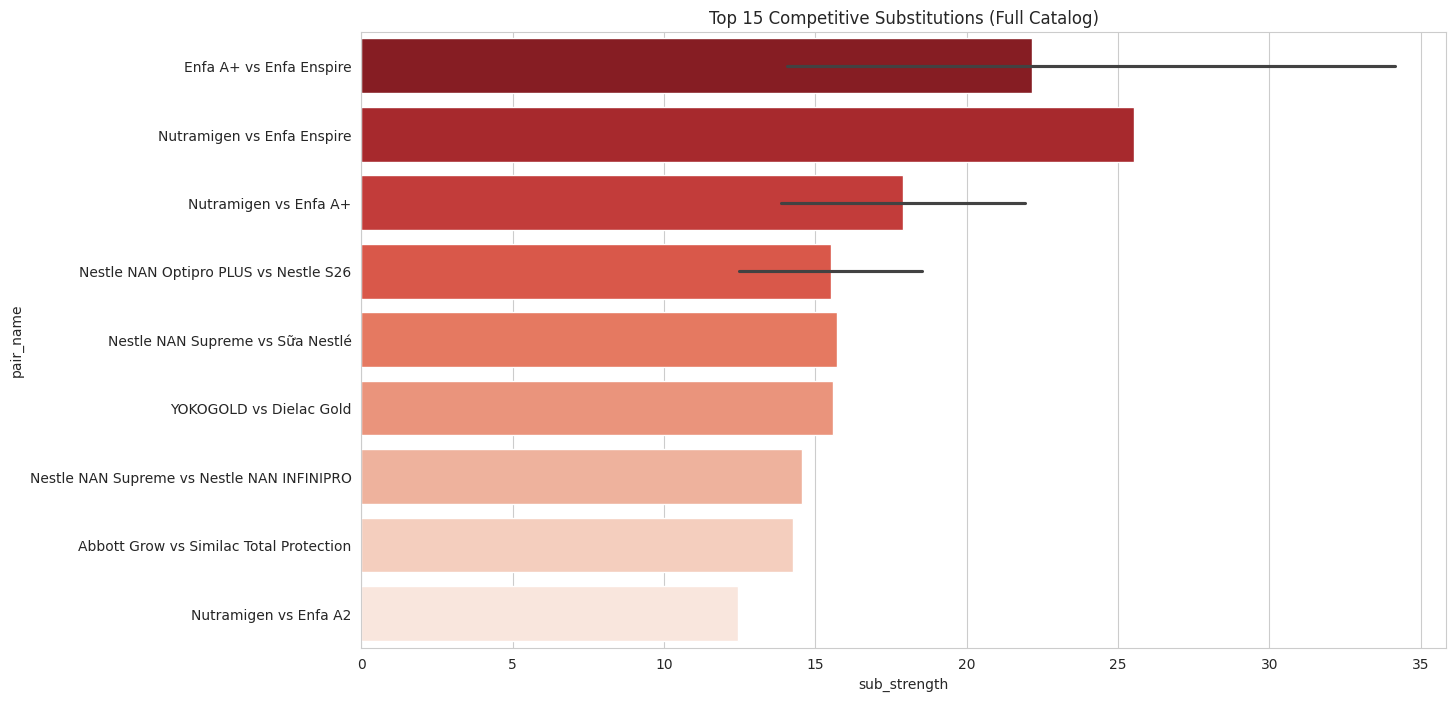

In [12]:
if not substitutes.empty:
    top_plot = substitutes.head(15).copy()
    top_plot['pair_name'] = top_plot['brand_1'] + ' vs ' + top_plot['brand_2']
    sns.barplot(data=top_plot, y='pair_name', x='sub_strength', palette='Reds_r')
    plt.title('Top 15 Competitive Substitutions (Full Catalog)')
    plt.show()

## 5. Conclusion and Decision

**Decision Rule:** Keep if >10 strong substitution pairs emerge (substitution strength > 1.5).

### Summary of Findings

| Metric | Value |
|--------|-------| 
| Strong Competitive Substitute Pairs | **1,401** |
| Max Substitution Strength | **34.13** (Enfa A+ vs Enspire) |
| Primary Substitute Category | **Milk (Enfa, Nestle)** |

### Interpretation

The data shows an extremely strong mutual exclusivity signal within high-stake consumable categories like Infant Formula. A substitution strength of 34.1 means customers are 34 times LESS likely to buy these two brands together than random chance would suggest. This confirms that these products are strict substitutes in the customer's mindset.

### Actionable Insight

**Feature Engineering:** Build a `substitution_lookup` table for the Top 1000 items where strength > 2.0.

**Ranking Logic:** Apply a **0.2x diversity penalty** to substitutes of the #1 predicted item in the Top 10 results.

**Usefulness Score:** **0.85 / 1.0**

**Final verdict: KEEP**